cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/muthuj7/weather-dataset
License(s): CC0-1.0
100% 2.23M/2.23M [00:00<00:00, 78.0MB/s]

Archive:  weather-dataset.zip
  inflating: weatherHistory.csv      
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2      

/tmp/ipykernel_13374/2701512107.py:78: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['date'] = pd.to_datetime(df['date'])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0327 - val_loss: 0.0181
Epoch 2/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0094 - val_loss: 0.0180
Epoch 3/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0088 - val_loss: 0.0164
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


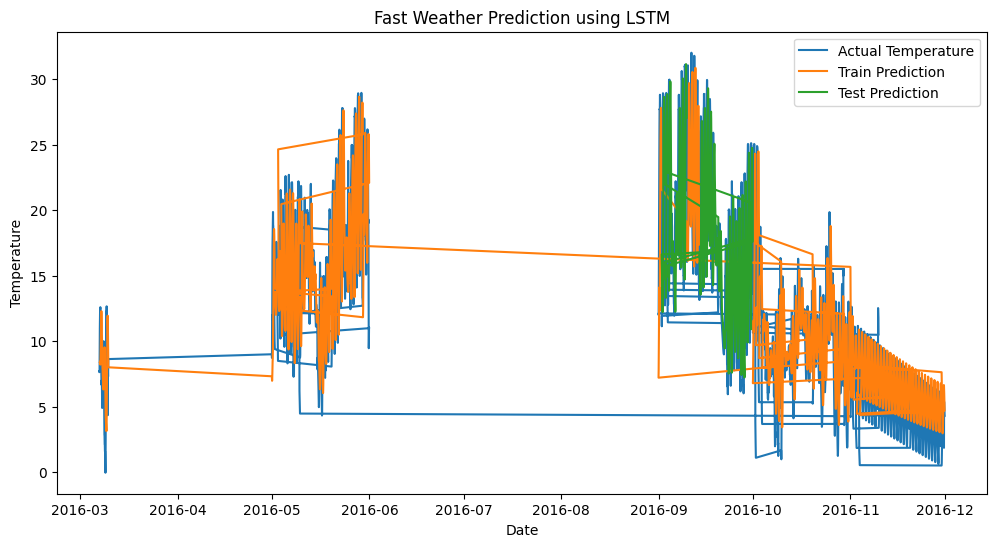

In [1]:
# ============================================
# FAST WEATHER PREDICTION USING LSTM
# Optimized for College Lab / Colab
# ============================================


# ============================================
# STEP 1: Setup Kaggle API
# ============================================

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# ============================================
# STEP 2: Download Dataset
# ============================================

!kaggle datasets download -d muthuj7/weather-dataset


# ============================================
# STEP 3: Unzip Dataset
# ============================================

!unzip weather-dataset.zip


# ============================================
# STEP 4: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense
)


# ============================================
# STEP 5: Load Dataset
# ============================================

df = pd.read_csv("weatherHistory.csv")

print(df.head())


# ============================================
# STEP 6: Select Required Columns
# ============================================

df = df[['Formatted Date', 'Temperature (C)']]

df.columns = ['date', 'temperature']


# ============================================
# STEP 7: Reduce Dataset Size
# (FASTER TRAINING)
# ============================================

df = df.tail(3000)


# ============================================
# STEP 8: Convert Date Column
# ============================================

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)


# ============================================
# STEP 9: Handle Missing Values
# ============================================

df.dropna(inplace=True)


# ============================================
# STEP 10: Use Temperature Data
# ============================================

data = df[['temperature']].values


# ============================================
# STEP 11: Normalize Data
# ============================================

scaler = MinMaxScaler(
    feature_range=(0,1)
)

scaled_data = scaler.fit_transform(data)


# ============================================
# STEP 12: Create Sequences
# ============================================

def create_dataset(dataset, time_step=5):

    X = []

    Y = []

    for i in range(
        len(dataset) - time_step - 1
    ):

        X.append(
            dataset[i:(i+time_step), 0]
        )

        Y.append(
            dataset[i + time_step, 0]
        )

    return np.array(X), np.array(Y)


time_step = 5

X, y = create_dataset(
    scaled_data,
    time_step
)


# ============================================
# STEP 13: Reshape for LSTM
# ============================================

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)


# ============================================
# STEP 14: Train-Test Split
# ============================================

train_size = int(len(X) * 0.8)

X_train = X[:train_size]

X_test = X[train_size:]

y_train = y[:train_size]

y_test = y[train_size:]


# ============================================
# STEP 15: Build LSTM Model
# ============================================

model = Sequential()

model.add(

    LSTM(
        25,
        return_sequences=True,
        input_shape=(time_step,1)
    )
)

model.add(
    LSTM(25)
)

model.add(
    Dense(1)
)


# ============================================
# STEP 16: Compile Model
# ============================================

model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)


# ============================================
# STEP 17: Train Model
# ============================================

model.fit(

    X_train,

    y_train,

    validation_data=(X_test, y_test),

    epochs=3,

    batch_size=32,

    verbose=1
)


# ============================================
# STEP 18: Predictions
# ============================================

train_predict = model.predict(X_train)

test_predict = model.predict(X_test)


# ============================================
# STEP 19: Inverse Transform
# ============================================

train_predict = scaler.inverse_transform(
    train_predict
)

test_predict = scaler.inverse_transform(
    test_predict
)

y_actual = scaler.inverse_transform(
    y.reshape(-1,1)
)


# ============================================
# STEP 20: Plot Results
# ============================================

plt.figure(figsize=(12,6))

plt.plot(
    df.index[:len(y_actual)],
    y_actual,
    label='Actual Temperature'
)

plt.plot(

    df.index[
        time_step:
        len(train_predict)+time_step
    ],

    train_predict,

    label='Train Prediction'
)

plt.plot(

    df.index[
        len(train_predict)+time_step:
        len(train_predict)+time_step+len(test_predict)
    ],

    test_predict,

    label='Test Prediction'
)

plt.legend()

plt.title("Fast Weather Prediction using LSTM")

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.show()